# Introduction to Subject 1523 VO2 Analysis
## A Step-By-Step Analysis
Performed by Olivia Mappalakayil

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/oliviamappalakayil/sub1523-vo2-data/subject_1523.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/oliviamappalakayil/sub1523-vo2-data/subject_1523.csv', header=[0], skiprows=[1,2,3])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TIME         54 non-null     float64
 1    "VO2   "    54 non-null     float64
 2    "VO2/kg  "  54 non-null     float64
 3    "METS "     54 non-null     float64
 4    "VCO2  "    54 non-null     float64
 5    "VE     "   54 non-null     float64
 6    "RER  "     54 non-null     float64
 7    "RR  "      54 non-null     float64
 8    "Vt    "    54 non-null     float64
 9    "FEO2  "    54 non-null     float64
 10   "FECO2 "    54 non-null     float64
 11   "HR  "      54 non-null     float64
 12   "VE/   "    54 non-null     float64
 13   "VE/   ".1  54 non-null     float64
 14   "PetCO2 "   54 non-null     float64
 15  PO           54 non-null     int64  
dtypes: float64(15), int64(1)
memory usage: 6.9 KB


#### Renaming Columns

In [4]:
df = df.rename(columns={'VE/': 'VE/VO2','VE/.1': 'VE/VCO2'})

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TIME         54 non-null     float64
 1    "VO2   "    54 non-null     float64
 2    "VO2/kg  "  54 non-null     float64
 3    "METS "     54 non-null     float64
 4    "VCO2  "    54 non-null     float64
 5    "VE     "   54 non-null     float64
 6    "RER  "     54 non-null     float64
 7    "RR  "      54 non-null     float64
 8    "Vt    "    54 non-null     float64
 9    "FEO2  "    54 non-null     float64
 10   "FECO2 "    54 non-null     float64
 11   "HR  "      54 non-null     float64
 12   "VE/   "    54 non-null     float64
 13   "VE/   ".1  54 non-null     float64
 14   "PetCO2 "   54 non-null     float64
 15  PO           54 non-null     int64  
dtypes: float64(15), int64(1)
memory usage: 6.9 KB


In [6]:
# Strip quotes and extra spaces from all column names
df.columns = df.columns.str.replace('"', '').str.strip()

# Check the results
print(df.columns)

import re

# Removing ALL non-alphanumeric charactersexcept underscores and slashes
# collapsing multiple spaces into one.
df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]

# Renaming Columns
df = df.rename(columns={
    'VE/': 'VE_VO2',
    'VE/ .1': 'VE_VCO2',
    'VE/.1': 'VE_VCO2' 
})

print(df.columns.tolist())

Index(['TIME', 'VO2', 'VO2/kg', 'METS', 'VCO2', 'VE', 'RER', 'RR', 'Vt',
       'FEO2', 'FECO2', 'HR', 'VE/', 'VE/   .1', 'PetCO2', 'PO'],
      dtype='object')
['TIME', 'VO2', 'VO2/kg', 'METS', 'VCO2', 'VE', 'RER', 'RR', 'Vt', 'FEO2', 'FECO2', 'HR', 'VE_VO2', 'VE_VCO2', 'PetCO2', 'PO']


In [7]:
import matplotlib.pyplot as plt

### Creating the Primary VO2 Plot: 
Minute ventilation (VE) and Oxygen Consumption (VO2) are plotted against time in minutes, where VO2 measures the body's ability to metabolically consume O2 during incremental physical exerction, and VE measures the amount of air entering the lungs per minute. 

#### 1. Defining variables x, y, and y1

In [8]:
# simplify our terms to reduce future typing...
x = df['TIME']
y = df['VO2']
y1 = df['VE']

In [9]:
#Find VO2 max value 
ymax = max(y)

# find the x position of the ymax value or where ymax occurs on the x axis
xmax = x[y.argmax()]

In [10]:
print(ymax)
print(xmax)

4.184775
26.500189


#### 2. Creating the axis

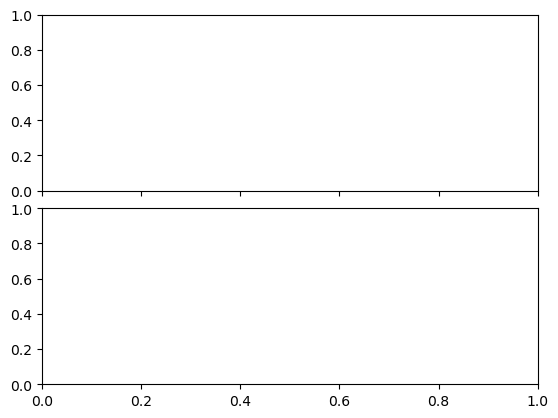

In [11]:
# break up the figure and axis definitions of a plot 
# so it is easier to assign values

fig, ax = plt.subplots(2, 1, sharex=True)

# create 2 subplots share x axis, in the next line we will remove 
# spaces between the horizontal axis, play with this value to see what happens the value can be 0.01 for example

fig.subplots_adjust(hspace=0.1
                   )

In [12]:
ax[0].annotate('$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ 1),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )

Text(27.000189, 5.184775, '$\\dot VO_2max$ =(4.18) L/min')

In [13]:
ax[0].plot(x, y,  label=('$\dot VO_2$'), c='r' )
ax[0].spines[['right', 'top']].set_visible(False)
#note all these set features could be added in one line but reading it would be difficult
#ax.set(title = ('$\dot VO_2$'), label=('$\dot VO_2$ L/min'))  
ax[0].set(ylabel=('L/min'))
ax[0].legend()


In [14]:
# Second plot of values down from the top
ax[1].plot(x, y1, label=('VE'), c='b')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].set(ylabel=('L/min'))
ax[1].legend()

In [15]:
fig.savefig("VO2-VE-3.png", dpi=300, bbox_inches = "tight")

#### 3. Placing code together for it to plot out interactively

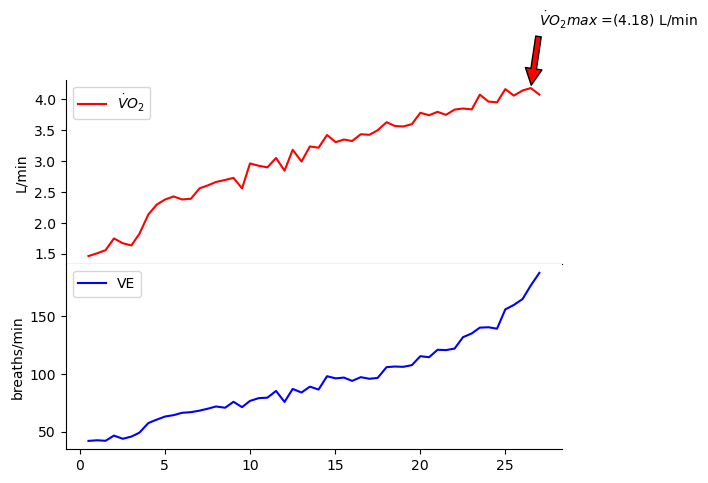

In [16]:
# break up the figure and axis definitions of a plot 
# so it is easier to assign values
fig, ax = plt.subplots(2, 1, sharex=True)  # Height increased from default
# spaces between the horizontal axis, play with this value?
fig.subplots_adjust(hspace=0)


ax[0].annotate('$\dot VO_2max$ =({}) L/min'.format(round(ymax, 2)), 
               xy=(xmax, ymax), xytext=(xmax+.5, ymax+ 1),
               arrowprops=dict(facecolor='red', shrink= 0.05),
                )

ax[0].plot(x, y,  label=('$\dot VO_2$'), c='r' )
ax[0].spines[['right', 'top']].set_visible(False)
#note all these set features could be added in one line but reading it would be difficult
#ax.set(title = ('$\dot VO_2$'), label=('$\dot VO_2$ L/min'))  
ax[0].set(ylabel=('L/min'))
ax[0].legend()

# Second plot of values down from the top
ax[1].plot(x, y1, label=('VE'), c='b')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].set(ylabel=('breaths/min'))
ax[1].legend()

#ax[0].set_ylim(min(y) - 1, max(y) + 1)  # Adjust as needed for your data
#ax[1].set_ylim(min(y1) - 1, max(y1) + 1)  # Adjust as needed

# save the figure before we show it... or it will be blank
fig.savefig("VO2-VE-3.png", dpi=300, bbox_inches = "tight")
fig.show()

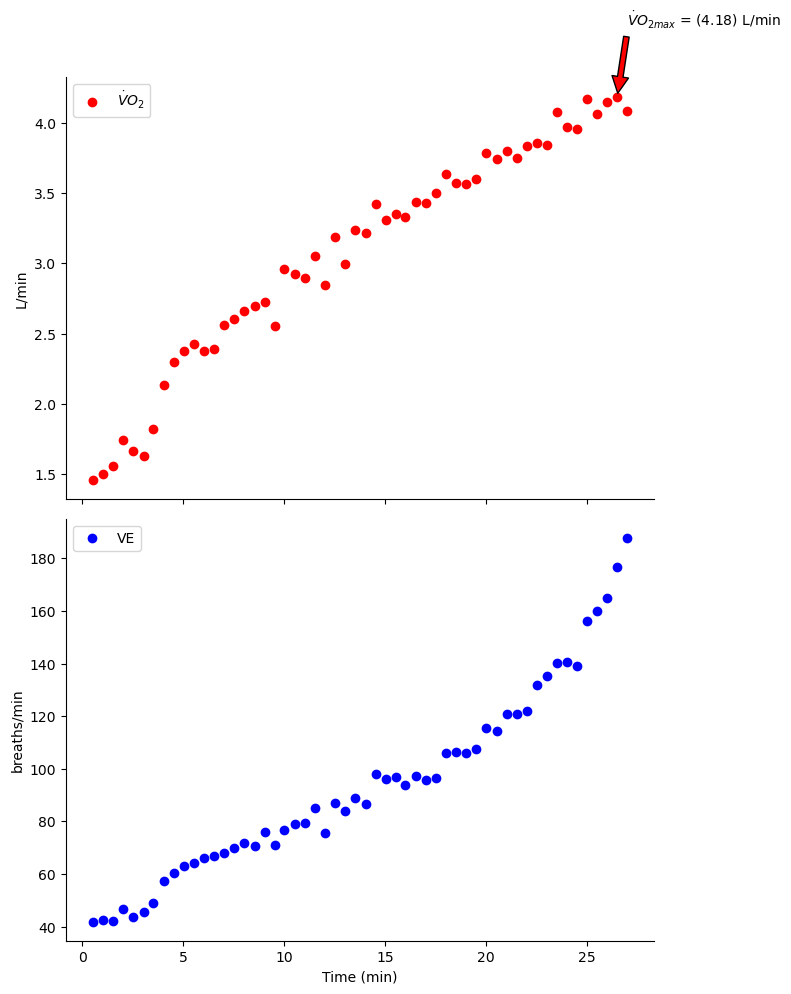

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. READ DATA
# Using your specific path
FILE_PATH = '/kaggle/input/datasets/oliviamappalakayil/sub1523-vo2-data/subject_1523.csv'
df = pd.read_csv(FILE_PATH, header=0, skiprows=[1,2,3])

# 2. CLEAN COLUMN HEADERS (The Fix for KeyError)
# This removes quotes, extra spaces, and forces everything to UPPERCASE
df.columns = [col.replace('"', '').strip().upper() for col in df.columns]

# Rename the specific ventilatory equivalent columns
# Note: Since we used .upper() above, the keys must be uppercase here
df = df.rename(columns={'VE/': 'VE_VO2', 'VE/.1': 'VE_VCO2'})

# 3. DEFINE VARIABLES
# Now 'TIME', 'VO2', and 'VE' will match exactly what is in df.columns
x = df['TIME']
y = df['VO2']
y1 = df['VE']

# Find VO2 max value and its exact time position
ymax = y.max()
xmax = x.iloc[y.argmax()] 

# 4. CREATE PLOT
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0)

# --- TOP PLOT (VO2) ---
# Added 'r' to strings to prevent SyntaxWarnings
ax[0].annotate(r'$\dot{V}O_{2max}$ = ' + f'({round(ymax, 2)}) L/min', 
               xy=(xmax, ymax), 
               xytext=(xmax + 0.5, ymax + 0.5),
               arrowprops=dict(facecolor='red', shrink=0.05))

ax[0].plot(x, y, 'o', label=r'$\dot{V}O_2$', c='r')
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_ylabel('L/min')
ax[0].legend()

# --- BOTTOM PLOT (VE) ---
ax[1].plot(x, y1, 'o', label='VE', c='b')
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set_ylabel('breaths/min')
ax[1].set_xlabel('Time (min)')
ax[1].legend()

# 5. SAVE AND SHOW
plt.tight_layout()
fig.savefig("VO2-VE-Final.png", dpi=300, bbox_inches="tight")
plt.show()

## Implementing the Gas Exchange Threshold (GET) and Respiratory Compensation Point (RCP)
#### 1. Cleaning up headers

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.signal import savgol_filter

# 1. READ DATA
FILE_PATH = '/kaggle/input/datasets/oliviamappalakayil/sub1523-vo2-data/subject_1523.csv'
df = pd.read_csv(FILE_PATH, header=0, skiprows=[1,2,3])

# 2. CLEAN COLUMN HEADERS (Removing quotes and hidden spaces)
df.columns = [col.replace('"', '').strip() for col in df.columns]

# Rename by position to ensure VE/VO2 and VE/VCO2 are identified correctly
cols = list(df.columns)
cols[12] = 'VE_VO2'
cols[13] = 'VE_VCO2'
df.columns = cols

# Define Global Variables for easier calling
time = df['TIME']
vo2 = df['VO2']
ve = df['VE']
vco2 = df['VCO2']
feco2 = df['FECO2']
ve_vo2 = df['VE_VO2']
ve_vco2 = df['VE_VCO2']

print("Dataset loaded and cleaned successfully.")

Dataset loaded and cleaned successfully.


#### 2. Implementing Automated Threshold Detection
This uses the Nadir Method to find the lowest point of the ventilatory equivalents. These points represent the transition between metabolic phases, and is used reputably for threshold detection. 

In [19]:
# Savitzky-Golay Smoothing
win = 11 
ve_vo2_s = savgol_filter(ve_vo2.values, win, 2)
ve_vco2_s = savgol_filter(ve_vco2.values, win, 2)

# GET (T1) Identification
# Physiological Basis: The nadir (lowest point) of the VE/VO2 curve.
# search the middle 60% of the test to avoid start-up noise.
start_search = int(len(df) * 0.15)
end_search = int(len(df) * 0.75)
get_idx = start_search + np.argmin(ve_vo2_s[start_search:end_search])
get_vo2 = vo2.iloc[get_idx]

# RCP (T2) Identification
# Physiological Basis: The nadir of the VE/VCO2 curve occurring AFTER GET.
rcp_idx = (get_idx + 5) + np.argmin(ve_vco2_s[get_idx + 5:end_search])
rcp_vo2 = vo2.iloc[rcp_idx]

print(f"Automated Detection Complete:")
print(f"GET (T1): {get_vo2:.2f} L/min")
print(f"RCP (T2): {rcp_vo2:.2f} L/min")

Automated Detection Complete:
GET (T1): 2.73 L/min
RCP (T2): 2.84 L/min


#### 3. Reproducing the Primary $\dot{V}O_2$ and $\dot{V}E$ Plot

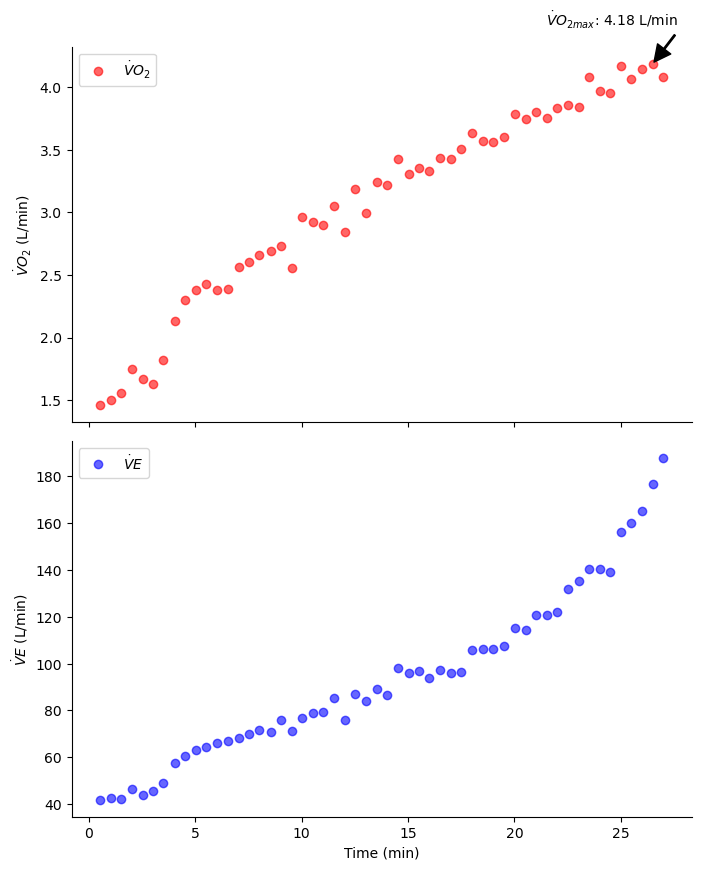

In [20]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0.05)

# Top Plot: VO2
ymax = vo2.max()
xmax = time[vo2.argmax()]
ax[0].plot(time, vo2, 'o', color='red', alpha=0.6, label=r'$\dot{V}O_2$')
ax[0].annotate(f'$\dot{{V}}O_{{2max}}$: {ymax:.2f} L/min', 
                xy=(xmax, ymax), xytext=(xmax-5, ymax+0.3),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1))
ax[0].set_ylabel('$\dot{V}O_2$ (L/min)')
ax[0].legend(loc='upper left')

# Bottom Plot: VE
ax[1].plot(time, ve, 'o', color='blue', alpha=0.6, label='$\dot{V}E$')
ax[1].set_ylabel('$\dot{V}E$ (L/min)')
ax[1].set_xlabel('Time (min)')
ax[1].legend(loc='upper left')

for a in ax: a.spines[['top', 'right']].set_visible(False)
plt.show()

#### 4. Rendering Gas Exchange Plots

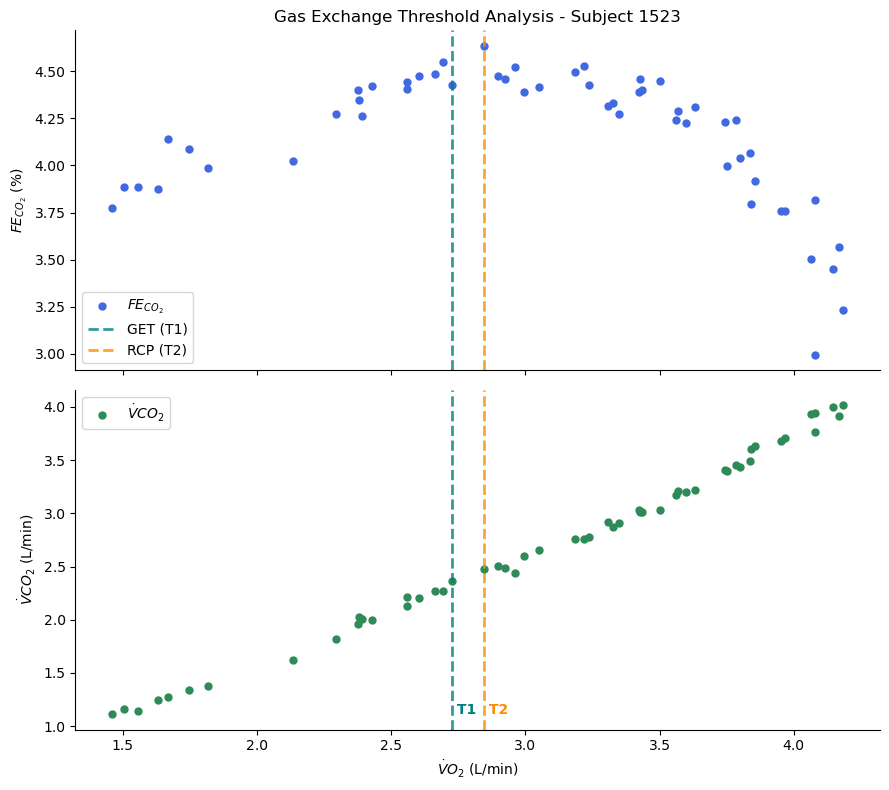

In [21]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(9, 8))
fig.subplots_adjust(hspace=0.1)

# Threshold Line Style
line_style = {'linestyle': '--', 'linewidth': 2, 'alpha': 0.8}

# Top: FECO2 vs VO2
ax[0].scatter(vo2, feco2, color='royalblue', s=25, label=r'$FE_{CO_2}$')
ax[0].axvline(get_vo2, color='teal', label=f'GET (T1)', **line_style)
ax[0].axvline(rcp_vo2, color='darkorange', label=f'RCP (T2)', **line_style)
ax[0].set_ylabel(r'$FE_{CO_2}$ (%)')
ax[0].set_title('Gas Exchange Threshold Analysis - Subject 1523')
ax[0].legend(loc='lower left')

# Bottom: VCO2 vs VO2
ax[1].scatter(vo2, vco2, color='seagreen', s=25, label=r'$\dot{V}CO_2$')
ax[1].axvline(get_vo2, color='teal', **line_style)
ax[1].axvline(rcp_vo2, color='darkorange', **line_style)
ax[1].text(get_vo2, vco2.min(), ' T1', color='teal', fontweight='bold')
ax[1].text(rcp_vo2, vco2.min(), ' T2', color='darkorange', fontweight='bold')

ax[1].set_ylabel(r'$\dot{V}CO_2$ (L/min)')
ax[1].set_xlabel(r'$\dot{V}O_2$ (L/min)')
ax[1].legend(loc='upper left')

for a in ax: a.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig('Gas_Exchange_Threshold_Analysis.png', dpi=300)
plt.show()

#### Conclusion

| Threshold                      | Label    | VO₂ (L/min) |
|--------------------------------|----------|-------------|
| Gas Exchange Threshold         | GET (T1) | 2.73        |
| Respiratory Compensation Point | RCP (T2) | 2.84        |

The identification of GET and RCP provides insight into the subject’s physiological responses to incremental exercise. The Gas Exchange Threshold (GET) reflects the onset of increased CO₂ production associated with bicarbonate buffering of lactate, marking the beginning of the isocapnic buffering phase. The Respiratory Compensation Point (RCP) represents a further increase in ventilation disproportionate to CO₂ output, occurring when buffering capacity is exceeded and metabolic acidosis drives hyperventilation.